# Class 23: Fourier Transforms

Ch. 7, sections 1-2: Fourier Transforms 
- Fourier series
- Discrete Fourier transforms

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [3]:
import numpy as np
import cmath 
import matplotlib.pyplot as plt

### Discrete Fourier Transforms 

Write a function that calculates the discrete Fourier transform (DFT) given by: 

$$ c_k = \sum_{n=0}^{N-1}y_n \exp\left(-i \frac{2\pi kn}{N}\right) $$

In [6]:
def DFT(y):
    #determine the number of sample points
    N = len(y)
    #create array for fourier coeffic
    c = np.zeros(N//2+1,complex)
    #loop through to cal coeff
    for k in range(N//2+1):
        for n in range(N):
            c[k] += y[n]*cmath.exp(-2j*np.pi*k*n/N)
    return c









### Apply this function to `pitch.txt`

**(1)** First, read in and plot the data from `pitch.txt`

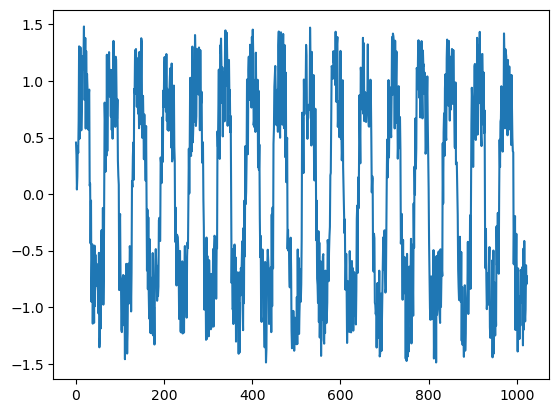

In [4]:
pitch_data = np.loadtxt("pitch.txt",float)
plt.plot(pitch_data)
plt.show()

**(2)** Apply your DFT function and plot the results 

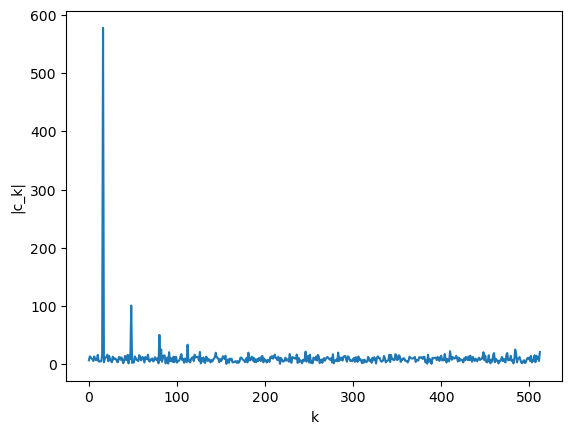

In [8]:
c_pitch = DFT(pitch_data)
plt.plot(np.abs(c_pitch))
plt.xlabel("k")
plt.ylabel("|c_k|")
plt.show()

### Exercise 7.2: Detecting Periodicity (part)

In the on-line resources there is a file called `sunspots.txt`, which contains the observed number of sunspots on the Sun for each month since January 1749. The file contains two columns of numbers, the first representing the month and the second being the sunspot number.

a) Write a program that reads the data in the file and makes a graph of sunspots as a function of time. You should see that the number of sunspots has fluctuated on a regular cycle for as long as observations have been recorded. Make an estimate of the length of the cycle in months.

b) Modify your program to calculate the Fourier transform of the sunspot data and then make a graph of the magnitude squared $|c_k|^2$ of the Fourier coefficients as a function of $k$—also called the power spectrum of the sunspot signal. You should see that there is a noticeable peak in the power spectrum at a nonzero value of $k$. The appearance of this peak tells us that there is one frequency in the Fourier series that has a higher amplitude than the others around it—meaning that there is a large sine-wave term with this frequency, which corresponds to the periodic wave you can see in the original data.

c) Find the approximate value of $k$ to which the peak corresponds. What is the period of the sine wave with this value of $k$? You should find that the period corresponds roughly to the length of the cycle that you estimated in part (a).

This kind of Fourier analysis is a sensitive method for detecting periodicity in signals. Even in cases where it is not clear to the eye that there is a periodic component to a signal, it may still be possible to find one using a Fourier transform.

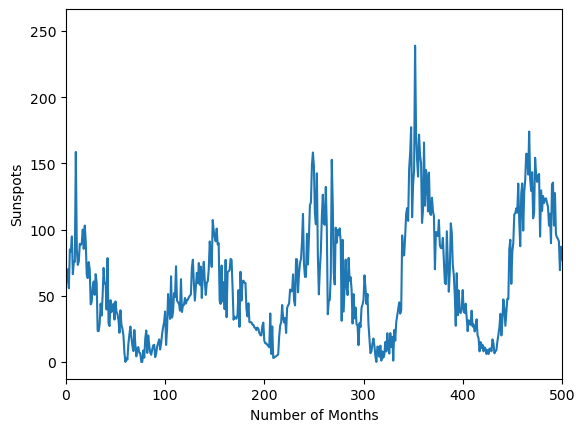

In [11]:
## part a
sun_data = np.loadtxt("sunspots.txt",float)
#separate the data

months = sun_data[:,0]
numspots = sun_data[:,1]

plt.plot(months, numspots)
plt.xlabel("Number of Months")
plt.ylabel("Sunspots")
plt.xlim(0,500)
plt.show()

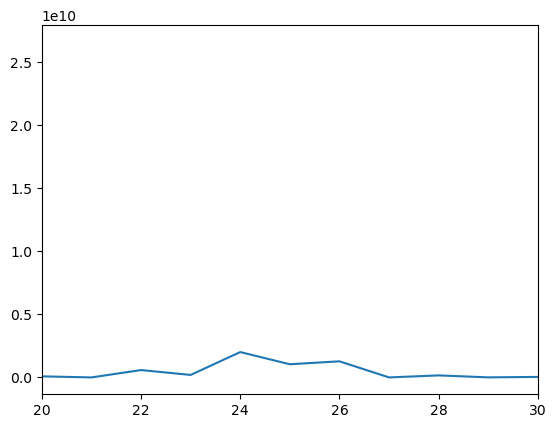

In [15]:
## part b - apply DFT function and calculate period 

ck_sunspots = DFT(numspots)

plt.plot(np.abs(ck_sunspots)**2)

plt.xlim(20,30)
plt.show()

In [16]:
## part (c)

k =24 
N = len(numspots)
period = N/k
print("the period is", period, "months, which is", period/12, "years")



the period is 130.95833333333334 months, which is 10.913194444444445 years
